# Approche par machine learning

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree
from sklearn.metrics import accuracy_score

In [3]:
import sys
sys.path.append("/home/onyxia/work/gtt/Anthony/ajout_ports.py")

from ajout_ports import associer_ports, distance_cote

In [4]:
nom_fichier = Path("/home/onyxia/work/data/data_indian_ocean.feather")

df = pd.read_feather(nom_fichier)

df.columns

navires_sample = pd.Series(df["mmsi"].unique()).sample(n=500, random_state=42)
df_sample = df[df["mmsi"].isin(navires_sample)].copy()

print(f"Taille du sample entier : {len(df_sample):,} lignes")
print(f"Navires : {df_sample['mmsi'].nunique()}")

# Échantillon de test
mmsi_sample = (
        pd.Series(df["mmsi"].dropna().unique())
        .sample(n=100, random_state=75)
    )
df_sample = df[df["mmsi"].isin(mmsi_sample)].copy()

print(f"===================================================")
print(f"Taille du sample utilisé : {len(df_sample):,} lignes")
print(f"Navires dans ce sample: {df_sample['mmsi'].nunique()}")

    # Pipeline complet
df_ports = associer_ports(df_sample, "upply-seaports.csv", seuil_cote_km=100)

# -------------------------------------------------------T)
# ------------------------------------------------------------------
def split_by_voyage(df, test_size=0.2):

    voyages = df["voyage number"].drop_duplicates()

    train_v, test_v = train_test_split(
        voyages, test_size=test_size, random_state=42
    )

    train_df = df[df["voyage number"].isin(train_v)]
    test_df = df[df["voyage number"].isin(test_v)]

    return train_df, test_df

Taille du sample entier : 7,790,471 lignes
Navires : 500
Taille du sample utilisé : 1,551,421 lignes
Navires dans ce sample: 100


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/onyxia/work/gtt/Mathias/ajout_ports.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist_cote_km"] = gdf.geometry.distance(cotes) * 111


In [5]:
# 3. Merge
df = df.merge(df_ports, on=["voyage number", "mmsi"], how="inner")

In [6]:
df.columns

Index(['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog',
       'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)',
       'destination', 'information source', 'checked status', 'load type',
       'voyage number', 'origin->destination', 'at port', 'port stay type',
       'wave period Tp (s)', 'significant wave height Hs (m)',
       'mean wave direction (°)', 'sea surface temperature (°K)',
       'air temperature at 2m (°K)', 'eastward wind velocity (m/s)',
       'northward wind velocity (m/s)',
       'mean wave direction relative to vessel (°)', 'lat_depart',
       'lon_depart', 'dist_depart', 'lat_arrivee', 'lon_arrivee',
       'dist_arrivee', 'port_depart_name', 'port_arrivee_name'],
      dtype='object')

In [ ]:
"""print("---- DEBUG ----")

print("Unique y_test:", np.unique(y_test))
print("Unique preds:", np.unique(y_pred))

print("\nDistribution vrai ports:")
print(test_df["port_arrivee_name"].value_counts().head())

print("\nExemple décodage:")
for i in range(5):
    print(
        le_target.inverse_transform([y_test.iloc[i]])[0],
        "vs",
        le_target.inverse_transform([y_pred[i]])[0]
    )
    """

---- DEBUG ----


NameError: name 'y_test' is not defined

In [8]:
# ------------------------------------------------------------------
# Features temporelles
# ------------------------------------------------------------------
def build_features(df):

    df = df.sort_values(["mmsi", "timestamp"]).copy()

    for lag in [1, 2]:
        df[f"lat_t-{lag}"] = df.groupby("mmsi")["latitude"].shift(lag)
        df[f"lon_t-{lag}"] = df.groupby("mmsi")["longitude"].shift(lag)

    return df.dropna()

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import xgboost as xgb

# 4. Features temporelles
df = build_features(df)

# 5. Nettoyage
df = df.dropna(subset=["port_depart_name", "port_arrivee_name"])

# 6. Split AVANT encodage
train_df, test_df = split_by_voyage(df)

# éviter warnings pandas
train_df = train_df.copy()
test_df = test_df.copy()

# 7. Encodage feature : port de départ
le_depart = LabelEncoder()
train_df["port_depart_enc"] = le_depart.fit_transform(train_df["port_depart_name"])

test_df = test_df[test_df["port_depart_name"].isin(le_depart.classes_)]
test_df["port_depart_enc"] = le_depart.transform(test_df["port_depart_name"])

# 8. Encodage target : port d’arrivée
le_target = LabelEncoder()
train_df["target_enc"] = le_target.fit_transform(train_df["port_arrivee_name"])

test_df = test_df[test_df["port_arrivee_name"].isin(le_target.classes_)]
test_df["target_enc"] = le_target.transform(test_df["port_arrivee_name"])

# 9. Features
FEATURES = [
    "latitude", "longitude",
    "port_depart_enc",
    "sog",  # speed over ground
    "cog",  # course over ground
    "dist_depart",
    #"dist_arrivee",
    "nav status code",
    "draft"
]

X_train = train_df[FEATURES]
y_train = train_df["target_enc"]

X_test = test_df[FEATURES]
y_test = test_df["target_enc"]

# 10. Modèle XGBoost (probabilités)
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.01,
    objective="multi:softprob",
    num_class=len(le_target.classes_),
    tree_method="hist",
    n_jobs=-1
)

model.fit(X_train, y_train)

# 11. Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# 12. Accuracy classique
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# 13. Top-K prédictions
TOP_K = 3

top_k_indices = np.argsort(y_proba, axis=1)[:, -TOP_K:][:, ::-1]

# convertir en noms de ports
top_k_ports = le_target.inverse_transform(top_k_indices.flatten())
top_k_ports = top_k_ports.reshape(top_k_indices.shape)

# 14. Top-K accuracy
def top_k_accuracy(y_true, top_k_preds):
    correct = 0
    for i in range(len(y_true)):
        if y_true.iloc[i] in top_k_preds[i]:
            correct += 1
    return correct / len(y_true)

top_k_acc = top_k_accuracy(y_test, top_k_indices)
print(f"Top-{TOP_K} Accuracy: {top_k_acc:.4f}")

Accuracy: 0.4398
Top-3 Accuracy: 0.7025


# Stats du modèle

Accuracy: 0.4398
Top-3 Accuracy: 0.7025


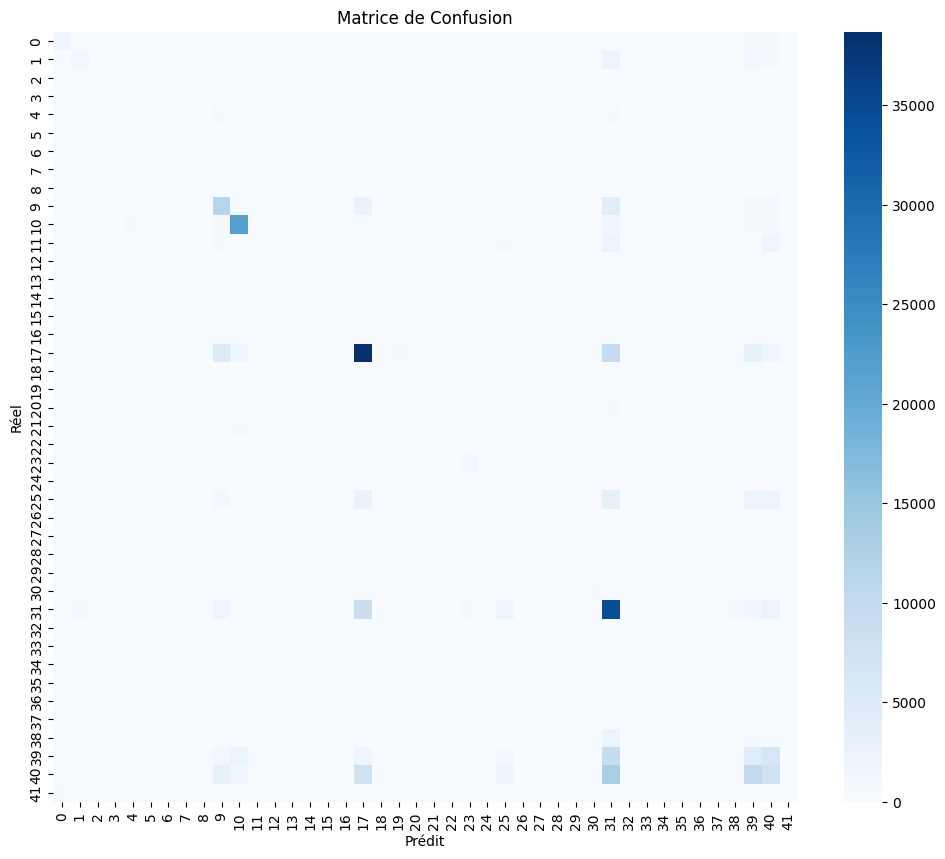

                            precision    recall  f1-score   support

               Anyer Kidul       0.56      0.44      0.49      4317
                Chattogram       0.39      0.22      0.28      5901
                    Cochin       0.00      0.00      0.00       144
                   Colombo       0.00      0.00      0.00       261
                     Dahej       0.11      0.12      0.11      1940
              Dighi (Pune)       0.00      0.00      0.00       430
                    Ennore       0.51      0.47      0.49       543
                     Fa'id       0.44      0.55      0.49     20991
                Goudiniweg       0.75      0.77      0.76     28608
                     Halul       0.00      0.00      0.00      5396
         Hazira Port/Surat       0.05      0.04      0.05       891
       Jebel Ali Free Zone       0.40      0.31      0.35       863
                    Jeddah       1.00      0.02      0.04        48
            Khor al Fakkan       0.61      0.63

/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Figure size 1000x600 with 0 Axes>

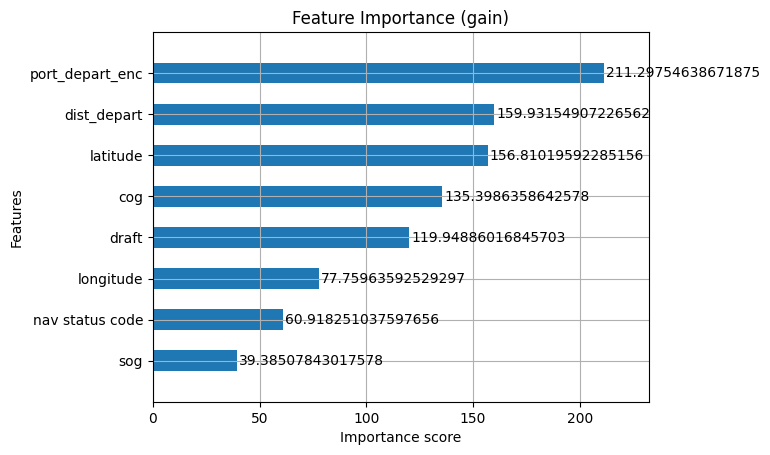

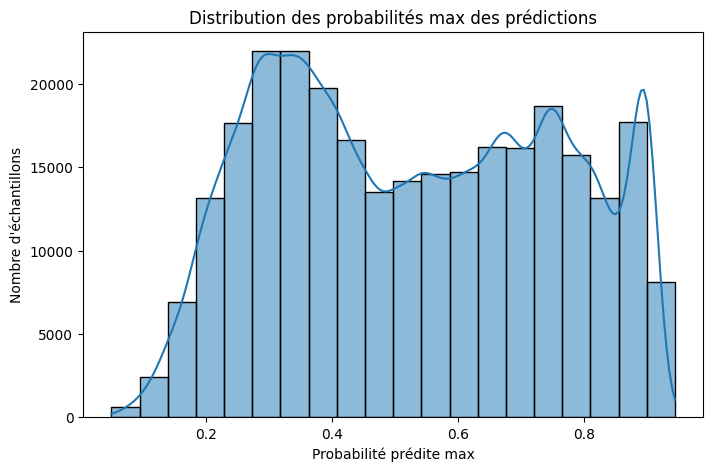

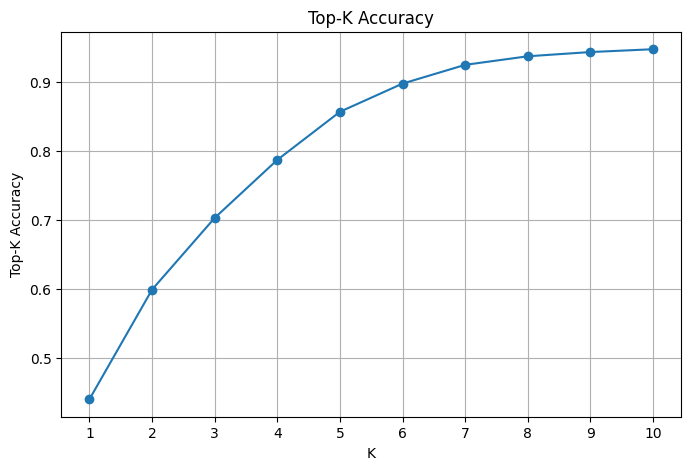

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. Accuracy et Top-K déjà calculés ---
print(f"Accuracy: {acc:.4f}")
print(f"Top-{TOP_K} Accuracy: {top_k_acc:.4f}")

# --- 2. Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Matrice de Confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# --- 3. Rapport classification ---
# Classes présentes dans le test
classes_test = le_target.classes_[np.sort(np.unique(y_test))]

print(classification_report(
    y_test, 
    y_pred, 
    labels=np.unique(y_test),    # les labels présents
    target_names=classes_test
))

# --- 4. Feature Importance ---
plt.figure(figsize=(10,6))
xgb.plot_importance(model, max_num_features=10, importance_type='gain', height=0.5)
plt.title("Feature Importance (gain)")
plt.show()

# --- 5. Distribution des probabilités max ---
max_proba = y_proba.max(axis=1)
plt.figure(figsize=(8,5))
sns.histplot(max_proba, bins=20, kde=True)
plt.title("Distribution des probabilités max des prédictions")
plt.xlabel("Probabilité prédite max")
plt.ylabel("Nombre d'échantillons")
plt.show()

# --- 6. Top-K coverage graphique ---
top_k_range = range(1, min(10, len(le_target.classes_)) + 1)
top_k_scores = []

for k in top_k_range:
    top_k_indices_k = np.argsort(y_proba, axis=1)[:, -k:][:, ::-1]
    score = top_k_accuracy(y_test, top_k_indices_k)
    top_k_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(top_k_range, top_k_scores, marker='o')
plt.title("Top-K Accuracy")
plt.xlabel("K")
plt.ylabel("Top-K Accuracy")
plt.xticks(top_k_range)
plt.grid(True)
plt.show()


# valeur moyenne sur les X derniers pas, ou depuis le départ
# 

In [14]:
# sauvegarde du modèle

import joblib

# Sauvegarder
joblib.dump(model, "xgb_model.pkl")

# Recharger plus tard
model_loaded = joblib.load("xgb_model.pkl")

# Recharger
#import xgboost as xgb
#model_loaded = xgb.XGBClassifier()
#model_loaded.load_model("xgb_model_1.json")

In [ ]:
df.head()

,imo,mmsi,name,latitude,longitude,timestamp,sog,cog,nav status,nav status code,...,dist_depart,lat_arrivee,lon_arrivee,dist_arrivee,port_depart_name,port_arrivee_name,lat_t-1,lon_t-1,lat_t-2,lon_t-2
1294002,9762261,215386000,FLEX ENDEAVOUR,2.222104,101.958828,2020-05-08T02:39:58.000000,15.000000,312.000000,Under Way Using Engine,0,...,6.944919,-35.101194,19.944919,33.189862,Tanjung Pelepas,Goudiniweg,2.061903,102.142458,1.922413,102.330933
1294005,9762261,215386000,FLEX ENDEAVOUR,2.686542,101.259852,2020-05-08T05:39:58.000000,18.000000,297.440278,Under Way Using Engine,0,...,6.944919,-35.101194,19.944919,33.189862,Tanjung Pelepas,Goudiniweg,2.541375,101.525438,2.384042,101.759771
1294006,9762261,215386000,FLEX ENDEAVOUR,2.819285,101.001497,2020-05-08T06:39:58.000000,15.744917,303.101664,Under Way Using Engine,0,...,6.944919,-35.101194,19.944919,33.189862,Tanjung Pelepas,Goudiniweg,2.686542,101.259852,2.541375,101.525438
1294007,9762261,215386000,FLEX ENDEAVOUR,3.013743,100.829789,2020-05-08T07:39:58.000000,15.440278,311.440278,Under Way Using Engine,0,...,6.944919,-35.101194,19.944919,33.189862,Tanjung Pelepas,Goudiniweg,2.819285,101.001497,2.686542,101.259852
1294008,9762261,215386000,FLEX ENDEAVOUR,3.228283,100.627747,2020-05-08T08:39:58.000000,18.000000,313.000000,Under Way Using Engine,0,...,6.944919,-35.101194,19.944919,33.189862,Tanjung Pelepas,Goudiniweg,3.013743,100.829789,2.819285,101.001497


## Archives

In [ ]:
# ------------------------------------------------------------------
# Associer ports (VERSION RAPIDE)
# ------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Fonctions principales
# ---------------------------------------------------------------------------
"""
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from shapely.strtree import STRtree
import geodatasets

# ⚡ cache global (évite de recalculer à chaque appel)
_COAST_TREE = None
_COAST_GEOMS = None

def _load_coast():
    global _COAST_TREE, _COAST_GEOMS

    if _COAST_TREE is None:
        world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
        world = world.to_crs(epsg=3857)

        _COAST_GEOMS = world.geometry.values
        _COAST_TREE = STRtree(_COAST_GEOMS)

def distance_cote_fast(df: pd.DataFrame) -> pd.DataFrame:
    _load_coast()

    df = df.copy()

    # projection directe
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    points = gdf.geometry.values

    # ⚡ calcul vectorisé avec STRtree
    distances = np.array([
        point.distance(_COAST_GEOMS[_COAST_TREE.nearest(point)])
        for point in points
    ])

    gdf["dist_cote_km"] = distances / 1000

    return gdf.drop(columns="geometry")


_PORTS_GDF = None

def _load_ports(seaports_csv):
    global _PORTS_GDF

    if _PORTS_GDF is None:
        ports_db = pd.read_csv(seaports_csv, sep=";", engine="python")
        ports_db = ports_db[["code", "name", "country_code", "latitude", "longitude"]].dropna()

        _PORTS_GDF = gpd.GeoDataFrame(
            ports_db,
            geometry=gpd.points_from_xy(ports_db["longitude"], ports_db["latitude"]),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)

    return _PORTS_GDF


def associer_ports_fast(df_ais, seaports_csv, seuil_cote_km=100):

    # ⚡ distance rapide
    df_ais = distance_cote_fast(df_ais)

    df_sorted = df_ais.sort_values("timestamp")

    ports = df_sorted.groupby(["voyage number", "mmsi"]).agg(
        lat_depart=("latitude", "first"),
        lon_depart=("longitude", "first"),
        dist_depart=("dist_cote_km", "first"),
        lat_arrivee=("latitude", "last"),
        lon_arrivee=("longitude", "last"),
        dist_arrivee=("dist_cote_km", "last"),
    ).reset_index()

    ports = ports[
        (ports["dist_depart"] < seuil_cote_km)
        & (ports["dist_arrivee"] < seuil_cote_km)
    ]

    gdf_ports = _load_ports(seaports_csv)

    def nearest_join(df, lon_col, lat_col, suffix):
        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)

        gdf = gpd.sjoin_nearest(
            gdf, gdf_ports, how="left", distance_col=f"dist_port_{suffix}"
        )

        return gdf[["voyage number", "mmsi", "name"]].rename(
            columns={"name": f"port_{suffix}_name"}
        )

    dep = nearest_join(ports, "lon_depart", "lat_depart", "depart")
    arr = nearest_join(ports, "lon_arrivee", "lat_arrivee", "arrivee")

    ports = ports.merge(dep, on=["voyage number", "mmsi"], how="left")
    ports = ports.merge(arr, on=["voyage number", "mmsi"], how="left")

    return ports


# ------------------------------------------------------------------
# Features temporelles
# ------------------------------------------------------------------
def build_features(df):

    df = df.sort_values(["mmsi", "timestamp"]).copy()

    for lag in [1, 2]:
        df[f"lat_t-{lag}"] = df.groupby("mmsi")["latitude"].shift(lag)
        df[f"lon_t-{lag}"] = df.groupby("mmsi")["longitude"].shift(lag)

    return df.dropna()
    """

'\nimport geopandas as gpd\nimport numpy as np\nfrom shapely.geometry import Point\nfrom shapely.strtree import STRtree\nimport geodatasets\n\n# ⚡ cache global (évite de recalculer à chaque appel)\n_COAST_TREE = None\n_COAST_GEOMS = None\n\ndef _load_coast():\n    global _COAST_TREE, _COAST_GEOMS\n\n    if _COAST_TREE is None:\n        world = gpd.read_file(geodatasets.get_path("naturalearth.land"))\n        world = world.to_crs(epsg=3857)\n\n        _COAST_GEOMS = world.geometry.values\n        _COAST_TREE = STRtree(_COAST_GEOMS)\n\ndef distance_cote_fast(df: pd.DataFrame) -> pd.DataFrame:\n    _load_coast()\n\n    df = df.copy()\n\n    # projection directe\n    gdf = gpd.GeoDataFrame(\n        df,\n        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),\n        crs="EPSG:4326"\n    ).to_crs(epsg=3857)\n\n    points = gdf.geometry.values\n\n    # ⚡ calcul vectorisé avec STRtree\n    distances = np.array([\n        point.distance(_COAST_GEOMS[_COAST_TREE.nearest(point)])